## High-Noise Data from Lagrange Orbits

---

**Problem Setup:** A PINN with initial conditions enforced through hard constraints was trained using highly noisy (20%) data generated from a Lagrange orbit. The PINN was able to fit the noisy data more effectively than a conventional neural network. However, during training, the data loss was observed to be significantly smaller than the PDE residual loss, indicating an imbalance between the loss components. This suggests that improved performance may be achieved through a more appropriate weighting of the loss terms.

**Observations and Remarks**

* All loss terms were assigned equal weights. A potentially better strategy would be to assign larger weights to the PDE residual terms.
* Initial conditions were enforced through hard constraints.
* The problem was rescaled using a similarity transformation such that the orbital period is (T=1), while preserving the form of the governing ODEs.



In [1]:
import os
os.environ["DDE_BACKEND"] = "tensorflow"

In [ ]:
!pip install deepxde

In [ ]:
!pip install tensorflow tf_keras matplotlib numpy scipy

## IMPORTS

In [ ]:
import deepxde as dde
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from numpy.linalg import norm

#Training

In [5]:
dde.config.set_default_float("float64")

seed=137
np.random.seed(seed)
tf.random.set_seed(seed)
dde.config.set_random_seed(seed)

# ============================================================
# Constants
# ============================================================
scale = 2
G = 1.0
m = [1.0, 1.0, 1.0]

endTime = 4 / scale**3

num_domain = 64
num_boundary = 12
num_test = 100

layer_size = [1] + [64]*3 + [6]
activation = "tanh"
initializer = "Glorot uniform"

iterations = 150000
learning_rate = 1e-4
loss_weights=[0.1]*6+[10]*6

eps = 1e-9

# ============================================================
# Initial Conditions
# ============================================================
omega = 0.3

x1_0, y1_0 = -1.0/scale**2, 0.0/scale**2
x2_0, y2_0 =  1.0/scale**2, 0.0/scale**2
x3_0, y3_0 =  0.0/scale**2, np.sqrt(3)/scale**2

vx1_0, vy1_0 = (-np.sqrt(3)/3)*omega*scale, 1*omega*scale
vx2_0, vy2_0 = (-np.sqrt(3)/3)*omega*scale, -1*omega*scale
vx3_0, vy3_0 = (2*np.sqrt(3)/3)*omega*scale, 0

y0 = np.array([x1_0,y1_0,x2_0,y2_0,x3_0,y3_0])
v0 = np.array([vx1_0,vy1_0,vx2_0,vy2_0,vx3_0,vy3_0])

y0_tf = tf.constant(y0)
v0_tf = tf.constant(v0)

# ============================================================
# NUMERICAL SOLUTION (for synthetic measurements)
# ============================================================

def three_body_numeric(t, y):

    x1,y1,vx1,vy1,x2,y2,vx2,vy2,x3,y3,vx3,vy3 = y

    r12 = np.sqrt((x1-x2)**2 + (y1-y2)**2 +eps)
    r13 = np.sqrt((x1-x3)**2 + (y1-y3)**2 +eps)
    r23 = np.sqrt((x2-x3)**2 + (y2-y3)**2 +eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    return [vx1,vy1,ax1,ay1,
            vx2,vy2,ax2,ay2,
            vx3,vy3,ax3,ay3]

t_span = (0,endTime)
t_eval = np.linspace(0,endTime,5000)

y0_full = [
x1_0,y1_0,vx1_0,vy1_0,
x2_0,y2_0,vx2_0,vy2_0,
x3_0,y3_0,vx3_0,vy3_0
]

sol = solve_ivp(three_body_numeric,t_span,y0_full,
                t_eval=t_eval,rtol=1e-10,atol=1e-12)

x1_n,y1_n = sol.y[0],sol.y[1]
x2_n,y2_n = sol.y[4],sol.y[5]
x3_n,y3_n = sol.y[8],sol.y[9]

# ============================================================
# SYNTHETIC NOISY MEASUREMENTS
# ============================================================

num_obs = 30
noise_level = 0.2

idx = np.sort(np.random.choice(len(t_eval),num_obs,replace=False))

t_obs = t_eval[idx][:,None]

y_obs_true = np.vstack([
x1_n[idx],y1_n[idx],
x2_n[idx],y2_n[idx],
x3_n[idx],y3_n[idx]
]).T

noise = noise_level*np.std(y_obs_true,axis=0)*np.random.randn(*y_obs_true.shape)

y_obs = y_obs_true + noise

# ============================================================
# PINN PDE
# ============================================================

def three_body_ode_second(t,y):

    x1,y1,x2,y2,x3,y3 = [y[:,i:i+1] for i in range(6)]

    r12 = tf.sqrt((x1-x2)**2 + (y1-y2)**2 + eps)
    r13 = tf.sqrt((x1-x3)**2 + (y1-y3)**2 + eps)
    r23 = tf.sqrt((x2-x3)**2 + (y2-y3)**2 + eps)

    ax1 = G*(m[1]*(x2-x1)/r12**3 + m[2]*(x3-x1)/r13**3)
    ay1 = G*(m[1]*(y2-y1)/r12**3 + m[2]*(y3-y1)/r13**3)

    ax2 = G*(m[0]*(x1-x2)/r12**3 + m[2]*(x3-x2)/r23**3)
    ay2 = G*(m[0]*(y1-y2)/r12**3 + m[2]*(y3-y2)/r23**3)

    ax3 = G*(m[0]*(x1-x3)/r13**3 + m[1]*(x2-x3)/r23**3)
    ay3 = G*(m[0]*(y1-y3)/r13**3 + m[1]*(y2-y3)/r23**3)

    x1_tt = dde.grad.hessian(y,t,component=0,i=0,j=0)
    y1_tt = dde.grad.hessian(y,t,component=1,i=0,j=0)
    x2_tt = dde.grad.hessian(y,t,component=2,i=0,j=0)
    y2_tt = dde.grad.hessian(y,t,component=3,i=0,j=0)
    x3_tt = dde.grad.hessian(y,t,component=4,i=0,j=0)
    y3_tt = dde.grad.hessian(y,t,component=5,i=0,j=0)

    return [
    x1_tt-ax1,
    y1_tt-ay1,
    x2_tt-ax2,
    y2_tt-ay2,
    x3_tt-ax3,
    y3_tt-ay3
    ]

# ============================================================
# Geometry
# ============================================================

geom = dde.geometry.TimeDomain(0,endTime)

# observation constraints
observe_x1 = dde.PointSetBC(t_obs,y_obs[:,0:1],component=0)
observe_y1 = dde.PointSetBC(t_obs,y_obs[:,1:2],component=1)
observe_x2 = dde.PointSetBC(t_obs,y_obs[:,2:3],component=2)
observe_y2 = dde.PointSetBC(t_obs,y_obs[:,3:4],component=3)
observe_x3 = dde.PointSetBC(t_obs,y_obs[:,4:5],component=4)
observe_y3 = dde.PointSetBC(t_obs,y_obs[:,5:6],component=5)

data = dde.data.PDE(
geom,
three_body_ode_second,
[
observe_x1,observe_y1,
observe_x2,observe_y2,
observe_x3,observe_y3
],
num_domain=num_domain,
num_boundary=num_boundary,
num_test=num_test
)

# ============================================================
# NETWORK
# ============================================================

net = dde.nn.FNN(layer_size,activation,initializer)

#=============================================================
# ICs enforced with output transformation -Hard Constrains
#=============================================================

def output_transform(t,y):
    return y0_tf + v0_tf*t + (t**2)*y

net.apply_output_transform(output_transform)

model = dde.Model(data,net)

model.compile("adam",lr=learning_rate,loss_weights=loss_weights)
losshistory,train_state = model.train(iterations=iterations)

#model.compile("L-BFGS")
#losshistory,train_state = model.train()

Set the default float type to float64
Compiling model...
'compile' took 0.009373 s

Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [2.34e+00, 2.52e-01, 1.17e+00, 1.34e+00, 4.03e-01, 2.41e+00, 5.51e-01, 3.55e-01, 1.44e-01, 7.32e-01, 6.33e-01, 2.70e-01]    [2.45e+00, 2.00e-01, 1.12e+00, 1.45e+00, 4.33e-01, 2.46e+00, 5.51e-01, 3.55e-01, 1.44e-01, 7.32e-01, 6.33e-01, 2.70e-01]    []  
1000      [9.44e-01, 9.72e-02, 1.04e-01, 9.04e-01, 5.02e-01, 5.34e-01, 2.05e-01, 6.82e-01, 5.07e-01, 3.62e-01, 5.98e-01, 2.77e-01]    [9.58e-01, 8.18e-02, 8.55e-02, 9.26e-01, 4.93e-01, 5.28e-01, 2.05e-01, 6.82e-01, 5.07e-01, 3.62e-01, 5.98e-01, 2.77e-01]    []  
2000      [2.91e-01, 1.53e-01, 5.08e-02, 3.71e-01, 3.55e-01, 1.34e-01, 3.46e-01, 4.15e-01, 5.51e-01, 

#Plots -Results

Saving loss history to /content/loss.dat ...
Saving training data to /content/train.dat ...
Saving test data to /content/test.dat ...


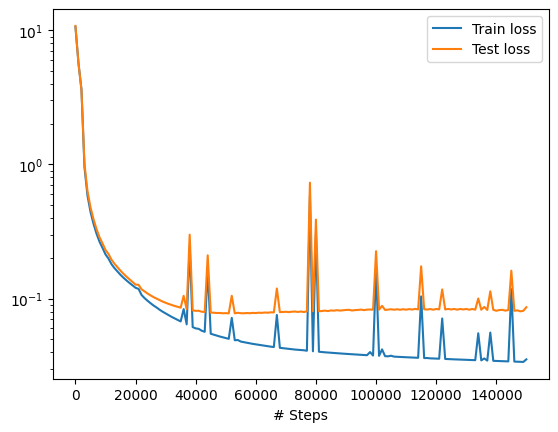

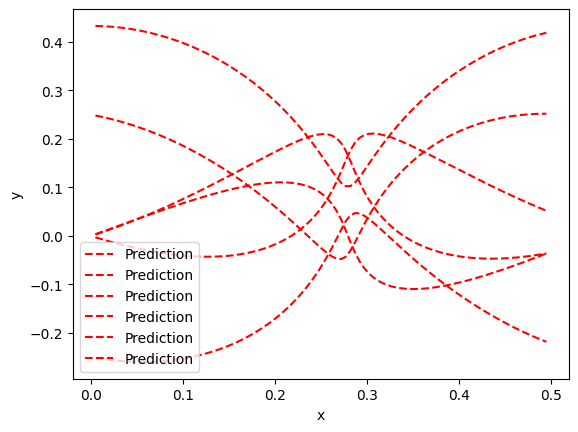

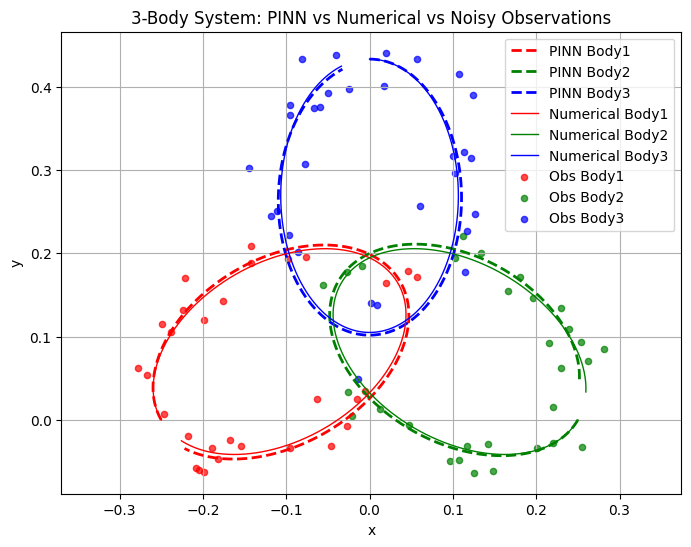


--- L2 Relative Errors ---
Body 1 x error: 4.66e-02
Body 1 y error: 7.10e-02
Body 2 x error: 5.16e-02
Body 2 y error: 9.89e-02
Body 3 x error: 7.41e-02
Body 3 y error: 2.63e-02


In [6]:
dde.saveplot(losshistory, train_state, issave=True, isplot=True)
# ============================================================
# PINN PREDICTION
# ============================================================

t_test = np.linspace(0,endTime,5000)[:,None]

y_pred = model.predict(t_test)

x1,y1 = y_pred[:,0],y_pred[:,1]
x2,y2 = y_pred[:,2],y_pred[:,3]
x3,y3 = y_pred[:,4],y_pred[:,5]

# ============================================================
# PLOTS
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(x1,y1,'r--',lw=2,label="PINN Body1")
plt.plot(x2,y2,'g--',lw=2,label="PINN Body2")
plt.plot(x3,y3,'b--',lw=2,label="PINN Body3")

plt.plot(x1_n,y1_n,'r-',lw=1,label="Numerical Body1")
plt.plot(x2_n,y2_n,'g-',lw=1,label="Numerical Body2")
plt.plot(x3_n,y3_n,'b-',lw=1,label="Numerical Body3")

# noisy measurements
plt.scatter(y_obs[:,0],y_obs[:,1],c='red',s=20,alpha=0.7,label="Obs Body1")
plt.scatter(y_obs[:,2],y_obs[:,3],c='green',s=20,alpha=0.7,label="Obs Body2")
plt.scatter(y_obs[:,4],y_obs[:,5],c='blue',s=20,alpha=0.7,label="Obs Body3")

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.axis("equal")

plt.title("3-Body System: PINN vs Numerical vs Noisy Observations")

plt.show()

# ============================================================
# Optional: Compute relative L2 errors
# ============================================================
interp_x1 = interp1d(t_eval, x1_n, kind='cubic')
interp_y1 = interp1d(t_eval, y1_n, kind='cubic')
interp_x2 = interp1d(t_eval, x2_n, kind='cubic')
interp_y2 = interp1d(t_eval, y2_n, kind='cubic')
interp_x3 = interp1d(t_eval, x3_n, kind='cubic')
interp_y3 = interp1d(t_eval, y3_n, kind='cubic')

x1_err = norm(x1 - interp_x1(t_test[:,0])) / norm(interp_x1(t_test[:,0]))
y1_err = norm(y1 - interp_y1(t_test[:,0])) / norm(interp_y1(t_test[:,0]))
x2_err = norm(x2 - interp_x2(t_test[:,0])) / norm(interp_x2(t_test[:,0]))
y2_err = norm(y2 - interp_y2(t_test[:,0])) / norm(interp_y2(t_test[:,0]))
x3_err = norm(x3 - interp_x3(t_test[:,0])) / norm(interp_x3(t_test[:,0]))
y3_err = norm(y3 - interp_y3(t_test[:,0])) / norm(interp_y3(t_test[:,0]))

print("\n--- L2 Relative Errors ---")
print(f"Body 1 x error: {x1_err:.2e}")
print(f"Body 1 y error: {y1_err:.2e}")
print(f"Body 2 x error: {x2_err:.2e}")
print(f"Body 2 y error: {y2_err:.2e}")
print(f"Body 3 x error: {x3_err:.2e}")
print(f"Body 3 y error: {y3_err:.2e}")

#STATISTICS

In [7]:
# ============================================================
# STATISTICS
# ============================================================


print("\n")
print("="*60)
print("STATISTICS")
print("="*60)

# ============================================================
# PINN velocities from automatic differentiation
# ============================================================

t_tf = tf.convert_to_tensor(t_test, dtype=tf.float64)

with tf.GradientTape() as tape:
    tape.watch(t_tf)
    y_pred_tf = model.net(t_tf)

dy_dt = tape.batch_jacobian(y_pred_tf, t_tf)

# remove singleton dimension
dy_dt = dy_dt[:, :, 0].numpy()

# PINN positions
y_pred = y_pred_tf.numpy()

x1, y1 = y_pred[:,0], y_pred[:,1]
x2, y2 = y_pred[:,2], y_pred[:,3]
x3, y3 = y_pred[:,4], y_pred[:,5]

# PINN velocities
vx1, vy1 = dy_dt[:,0], dy_dt[:,1]
vx2, vy2 = dy_dt[:,2], dy_dt[:,3]
vx3, vy3 = dy_dt[:,4], dy_dt[:,5]

# ============================================================
# Numerical solution
# ============================================================

x1_n  = sol.y[0]
y1_n  = sol.y[1]
vx1_n = sol.y[2]
vy1_n = sol.y[3]

x2_n  = sol.y[4]
y2_n  = sol.y[5]
vx2_n = sol.y[6]
vy2_n = sol.y[7]

x3_n  = sol.y[8]
y3_n  = sol.y[9]
vx3_n = sol.y[10]
vy3_n = sol.y[11]

# ============================================================
# TRAIN / TEST LOSS
# ============================================================

train_losses = np.array(losshistory.loss_train)
test_losses  = np.array(losshistory.loss_test)

final_train_loss = np.sum(train_losses[-1])
final_test_loss  = np.sum(test_losses[-1])

# six PDE residuals
LPDE = np.sum(train_losses[-1][:6])

# six observation losses
LDATA = np.sum(train_losses[-1][6:])

print(f"Final Training Loss : {final_train_loss:.2e}")
print(f"Final Test Loss     : {final_test_loss:.2e}")
print(f"PDE Residual Loss   : {LPDE:.2e}")
print(f"Data Loss           : {LDATA:.2e}")

# ============================================================
# 2. POSITION ERRORS - RMSE
# ============================================================

err1 = np.sqrt((x1 - x1_n)**2 + (y1 - y1_n)**2)
err2 = np.sqrt((x2 - x2_n)**2 + (y2 - y2_n)**2)
err3 = np.sqrt((x3 - x3_n)**2 + (y3 - y3_n)**2)

rmse1 = np.sqrt(np.mean(err1**2))
rmse2 = np.sqrt(np.mean(err2**2))
rmse3 = np.sqrt(np.mean(err3**2))

RMSE = np.sqrt(np.mean(
    np.concatenate([
        err1**2,
        err2**2,
        err3**2
    ])
))

print("\nPosition RMSE")
print("-----------------------------")
print(f"Body 1 : {rmse1:.2e}")
print(f"Body 2 : {rmse2:.2e}")
print(f"Body 3 : {rmse3:.2e}")
print(f"Global : {RMSE:.2e}")

print("\nMaximum Position Error")
print("-----------------------------")
print(f"Body 1 : {np.max(err1):.2e}")
print(f"Body 2 : {np.max(err2):.2e}")
print(f"Body 3 : {np.max(err3):.2e}")

max_pos_error = max(
    np.max(err1),
    np.max(err2),
    np.max(err3)
)
print(f"Global Max Position error : {max_pos_error:.2e}")

# ============================================================
# 3. ENERGY
# ============================================================



def total_energy(x1,y1,vx1,vy1,
                 x2,y2,vx2,vy2,
                 x3,y3,vx3,vy3,
                 G=1.0,
                 m=(1.0,1.0,1.0),
                 eps=0.0):

    KE = (
        0.5*m[0]*(vx1**2+vy1**2)
        +0.5*m[1]*(vx2**2+vy2**2)
        +0.5*m[2]*(vx3**2+vy3**2)
    )

    r12 = np.sqrt((x1-x2)**2+(y1-y2)**2+eps)
    r13 = np.sqrt((x1-x3)**2+(y1-y3)**2+eps)
    r23 = np.sqrt((x2-x3)**2+(y2-y3)**2+eps)

    PE = (
        -G*m[0]*m[1]/r12
        -G*m[0]*m[2]/r13
        -G*m[1]*m[2]/r23
    )

    return KE + PE


E = total_energy(
    x1,y1,vx1,vy1,
    x2,y2,vx2,vy2,
    x3,y3,vx3,vy3,
    G,m,eps
)

E0 = E[0]

DE_E0 = np.max(np.abs(E-E0))/abs(E0)

print("\nEnergy Conservation")
print("-----------------------------")
print(f"PINN ΔE/E0 : {DE_E0:.2e}")

E_num = total_energy(
    x1_n, y1_n, vx1_n, vy1_n,
    x2_n, y2_n, vx2_n, vy2_n,
    x3_n, y3_n, vx3_n, vy3_n,
    G, m, eps
)

E0_num = E_num[0]

DE_E0_num = np.max(np.abs(E_num-E0_num))/abs(E0_num)


print("-----------------------------")
print(f"Numerical ΔE/E0 : {DE_E0_num:.2e}")

# ============================================================
# 4. LINEAR MOMENTUM DRIFT
# ============================================================

Px = m[0]*vx1 + m[1]*vx2 + m[2]*vx3
Py = m[0]*vy1 + m[1]*vy2 + m[2]*vy3

DeltaP = np.max(
    np.sqrt(
        (Px - Px[0])**2 +
        (Py - Py[0])**2
    )
)

print("\nLinear Momentum")
print("-----------------------------")
print(f"PINN Max Momentum Drift : {DeltaP:.2e}")

Px_n = m[0]*vx1_n + m[1]*vx2_n + m[2]*vx3_n
Py_n = m[0]*vy1_n + m[1]*vy2_n + m[2]*vy3_n

DeltaP_n = np.max(
    np.sqrt(
        (Px_n - Px_n[0])**2 +
        (Py_n - Py_n[0])**2
    )
)


print("-----------------------------")
print(f"Numerical Max Momentum Drift : {DeltaP_n:.2e}")


# ============================================================
# 5. ANGULAR MOMENTUM
# ============================================================

L = (
      m[0]*(x1*vy1-y1*vx1)
    + m[1]*(x2*vy2-y2*vx2)
    + m[2]*(x3*vy3-y3*vx3)
)

L0 = L[0]

DL_L0 = np.max(np.abs(L-L0))/max(abs(L0),1e-15)

print("\nAngular Momentum Conservation")
print("-----------------------------")
print(f"ΔL/L0 : {DL_L0:.2e}")


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("="*60)
print("SUMMARY")
print("="*60)

print(f"Final Training Loss               : {final_train_loss:.2e}")
print(f"Final Test Loss                   : {final_test_loss:.2e}")
print(f"PDE Residual Loss                 : {LPDE:.2e}")
print(f"Data Loss                         : {LDATA:.2e}")
print(f"Global Max Position error         : {max_pos_error:.2e}")
print(f"Position RMSE                     : {RMSE:.2e}")
print(f"PINN ΔE/E0                        : {DE_E0:.2e}")
print(f"Numerical ΔE/E0                   : {DE_E0_num:.2e}")
print(f"PINN Max Momentum Drift ΔP        : {DeltaP:.2e}")
print(f"Numerical Max Momentum Drift ΔP   : {DeltaP_n:.2e}")
print(f"ΔL/L0                             : {DL_L0:.2e}")



STATISTICS
Final Training Loss : 3.52e-02
Final Test Loss     : 8.62e-02
PDE Residual Loss   : 9.08e-03
Data Loss           : 2.61e-02

Position RMSE
-----------------------------
Body 1 : 1.10e-02
Body 2 : 1.35e-02
Body 3 : 1.06e-02
Global : 1.18e-02

Maximum Position Error
-----------------------------
Body 1 : 2.53e-02
Body 2 : 2.54e-02
Body 3 : 2.50e-02
Global Max Position error : 2.54e-02

Energy Conservation
-----------------------------
PINN ΔE/E0 : 1.80e-02
-----------------------------
Numerical ΔE/E0 : 9.48e-10

Linear Momentum
-----------------------------
PINN Max Momentum Drift : 1.16e-02
-----------------------------
Numerical Max Momentum Drift : 4.93e-15

Angular Momentum Conservation
-----------------------------
ΔL/L0 : 3.86e-02


SUMMARY
Final Training Loss               : 3.52e-02
Final Test Loss                   : 8.62e-02
PDE Residual Loss                 : 9.08e-03
Data Loss                         : 2.61e-02
Global Max Position error         : 2.54e-02
Positi